# Social Science Concept Integration Analysis
This notebook performs the analysis of various sentence transformer models for concept integration.
It uses a modular configuration setup for flexibility.

In [1]:
import pandas as pd
import model_utils_pairwise as model_utils
import model_utils_shared
import config
import warnings

# Silence warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Reproducibility Setup
SEED = model_utils_shared.setup_reproducibility(config.SEED)

/home/rass/Desktop/SocialScience-ConceptIntegration/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and Prepare Data
Load positive and negative pairs datasets using paths from the configuration.

In [2]:
pos_path = config.DATA_PATHS['pos_pairs']
neg_path = config.DATA_PATHS['neg_pairs']

df = model_utils_shared.load_and_prepare_data(pos_path, neg_path, SEED)
labels = df['label'].values
print(f"Total Rows: {len(df)}")
df.head()

Loading datasets...
Positive samples: 3587
Negative samples (total): 2884723
Negative samples (used as is): 2884723
Total Rows: 2888310


,term1,term2,concept_uri,label,shortest_path,concept1_uri,concept2_uri
0,CLINICAL TESTS AND MEASUREMENTS,BIOLOGY,NaN,0,-1,https://elsst.cessda.eu/id/5/83092545-76ae-476...,https://elsst.cessda.eu/id/5/9e14b50b-67f4-48b...
1,CARGO,TEACHER AUTHORITY,NaN,0,-1,https://elsst.cessda.eu/id/5/7a000a99-92c4-414...,https://elsst.cessda.eu/id/5/e1cbf083-6028-44c...
2,PRESS,EUROPEAN EXCHANGE RATE MECHANISM,NaN,0,14,https://elsst.cessda.eu/id/5/9d93585a-cf64-46f...,https://elsst.cessda.eu/id/5/e9b6e3ad-5094-422...
3,POPULATION INCREASE,INCOME DISTRIBUTION,NaN,0,-1,https://elsst.cessda.eu/id/5/9db0cd4c-64a3-4c7...,https://elsst.cessda.eu/id/5/f95d4a93-4490-4a8...
4,CHOIRS,PORNOGRAPHY,NaN,0,-1,https://elsst.cessda.eu/id/5/44f36c53-fc3f-457...,https://elsst.cessda.eu/id/5/661756c6-22da-42d...


## 2. Models to Evaluate
We iterate through models defined in `config.py`.
Models are categorized as 'sentence' (SentenceTransformer) or 'token' (Transformer + Mean Pooling).

In [3]:
models_to_test = config.MODELS
print("Models to be evaluated:")
for key, conf in models_to_test.items():
    print(f"- {conf['display_name']} ({key}) -> Type: {conf['type']}")

Models to be evaluated:
- All-MPNet-Base-v2 (all-mpnet-base-v2) -> Type: sentence_transformer
- MPNet-Personality (dwulff/mpnet-personality) -> Type: sentence_transformer
- SciBERT (SciVocab) (allenai/scibert_scivocab_uncased) -> Type: token_embedding_mean_pool
- BERT Base (bert-base-uncased) -> Type: token_embedding_mean_pool


## 3. Analysis Loop
Iterate through each model:
1. Load the model based on type.
2. Compute embeddings and cosine similarities.
3. Evaluate metrics across thresholds defined in config.
4. Generate high-quality visualizations.


 Processing: All-MPNet-Base-v2
Loading Model (all-mpnet-base-v2)...
Building unique concept set...
Encoding 4270 unique concepts...


Batches: 100%|██████████| 267/267 [00:16<00:00, 16.31it/s]


Computing Cosine Similarities for pairs...

--- Results per Threshold (all-mpnet-base-v2) ---
Threshold  | F1         | Precision  | Recall     | PosAcc     | NegAcc     | MCC       
-----------------------------------------------------------------------------------------------
0.10       | 0.0034     | 0.0017     | 0.9972     | 0.9972     | 0.2756     | 0.0215
0.11       | 0.0036     | 0.0018     | 0.9961     | 0.9961     | 0.3154     | 0.0236
0.12       | 0.0038     | 0.0019     | 0.9944     | 0.9944     | 0.3561     | 0.0258
0.13       | 0.0041     | 0.0020     | 0.9936     | 0.9936     | 0.3977     | 0.0282
0.14       | 0.0044     | 0.0022     | 0.9925     | 0.9925     | 0.4395     | 0.0307
0.15       | 0.0047     | 0.0024     | 0.9908     | 0.9908     | 0.4809     | 0.0333
0.16       | 0.0051     | 0.0026     | 0.9897     | 0.9897     | 0.5217     | 0.0361
0.17       | 0.0056     | 0.0028     | 0.9877     | 0.9877     | 0.5613     | 0.0390
0.18       | 0.0061     | 0.0031     | 0.

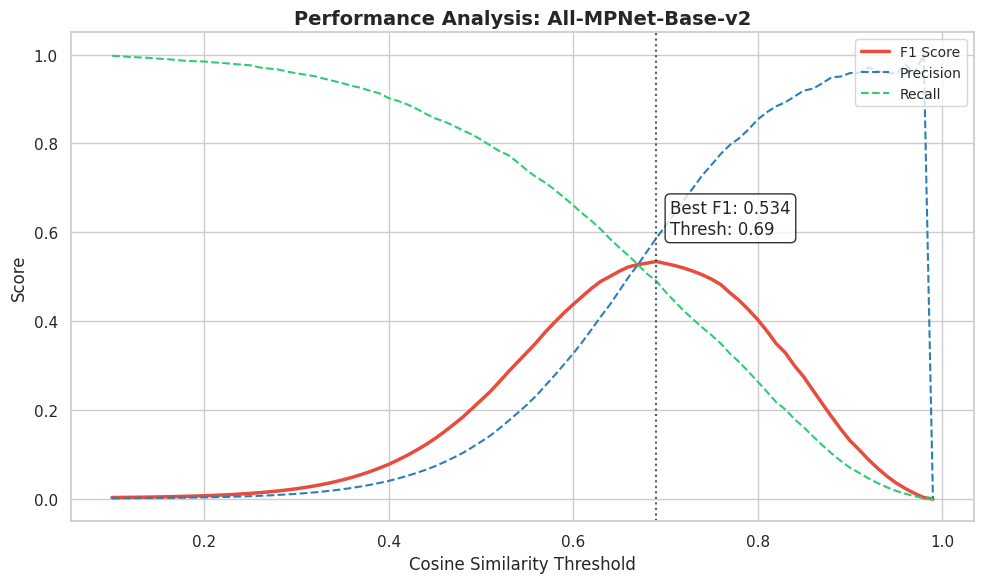


 Processing: MPNet-Personality
Loading Model (dwulff/mpnet-personality)...
Building unique concept set...
Encoding 4270 unique concepts...


Batches: 100%|██████████| 267/267 [00:18<00:00, 14.49it/s]


Computing Cosine Similarities for pairs...

--- Results per Threshold (dwulff/mpnet-personality) ---
Threshold  | F1         | Precision  | Recall     | PosAcc     | NegAcc     | MCC       
-----------------------------------------------------------------------------------------------
0.10       | 0.0041     | 0.0020     | 0.9953     | 0.9953     | 0.3922     | 0.0280
0.11       | 0.0046     | 0.0023     | 0.9941     | 0.9941     | 0.4600     | 0.0321
0.12       | 0.0052     | 0.0026     | 0.9933     | 0.9933     | 0.5267     | 0.0367
0.13       | 0.0060     | 0.0030     | 0.9911     | 0.9911     | 0.5902     | 0.0416
0.14       | 0.0069     | 0.0035     | 0.9869     | 0.9869     | 0.6490     | 0.0469
0.15       | 0.0081     | 0.0041     | 0.9824     | 0.9824     | 0.7017     | 0.0526
0.16       | 0.0096     | 0.0048     | 0.9794     | 0.9794     | 0.7483     | 0.0590
0.17       | 0.0114     | 0.0057     | 0.9774     | 0.9774     | 0.7885     | 0.0659
0.18       | 0.0135     | 0.0068  

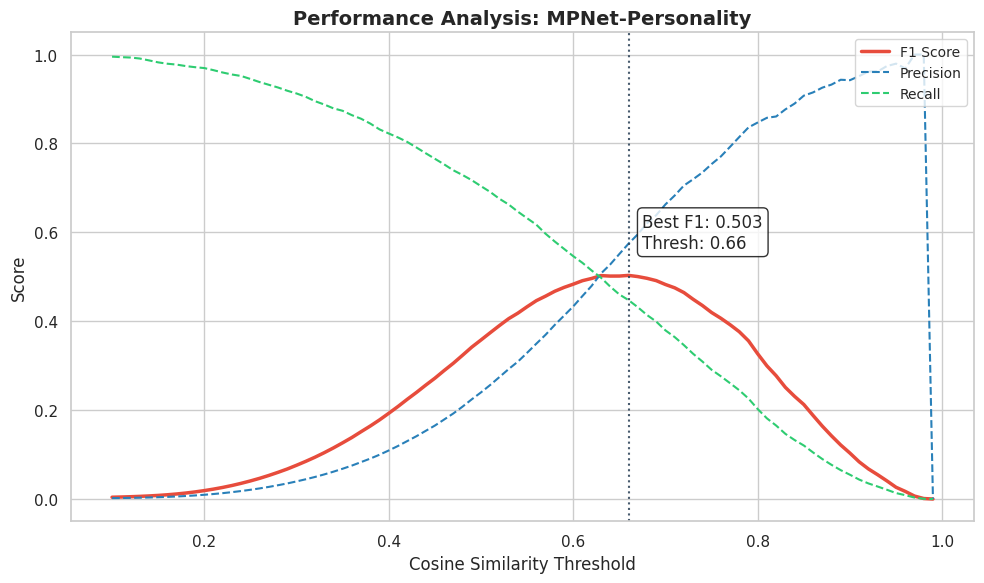


 Processing: SciBERT (SciVocab)
Loading Model (allenai/scibert_scivocab_uncased)...
Building unique concept set...
Encoding 4270 unique concepts...


Batches: 100%|██████████| 267/267 [00:13<00:00, 20.27it/s]


Computing Cosine Similarities for pairs...

--- Results per Threshold (allenai/scibert_scivocab_uncased) ---
Threshold  | F1         | Precision  | Recall     | PosAcc     | NegAcc     | MCC       
-----------------------------------------------------------------------------------------------
0.10       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0000
0.11       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0000
0.12       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0000
0.13       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0000
0.14       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0000
0.15       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0000
0.16       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0000
0.17       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0000
0.18       | 0.0025     | 

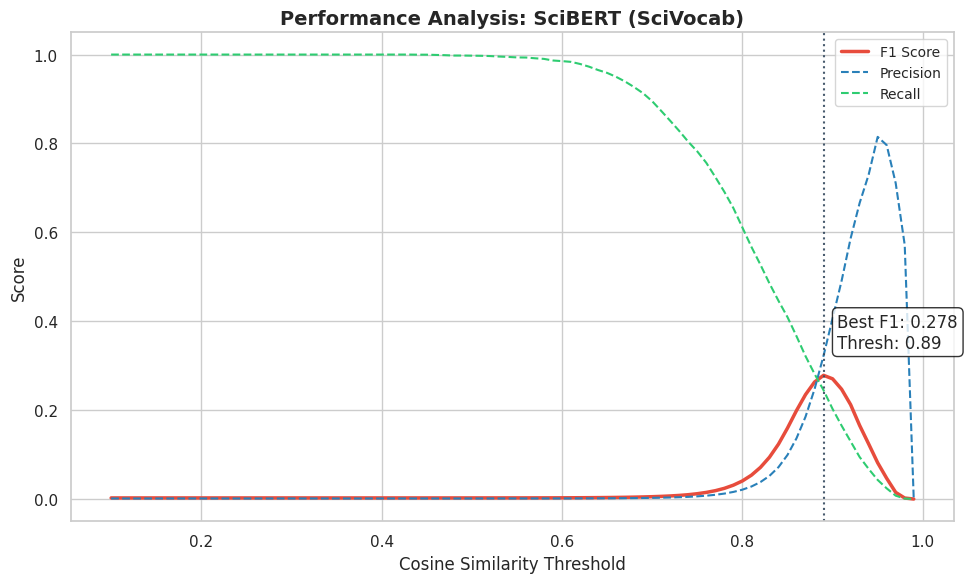


 Processing: BERT Base
Loading Model (bert-base-uncased)...
Building unique concept set...
Encoding 4270 unique concepts...


Batches: 100%|██████████| 267/267 [00:13<00:00, 20.11it/s]


Computing Cosine Similarities for pairs...

--- Results per Threshold (bert-base-uncased) ---
Threshold  | F1         | Precision  | Recall     | PosAcc     | NegAcc     | MCC       
-----------------------------------------------------------------------------------------------
0.10       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0000
0.11       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0000
0.12       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0001
0.13       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0001
0.14       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0001
0.15       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0001
0.16       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0002
0.17       | 0.0025     | 0.0012     | 1.0000     | 1.0000     | 0.0000     | 0.0002
0.18       | 0.0025     | 0.0012     | 1.

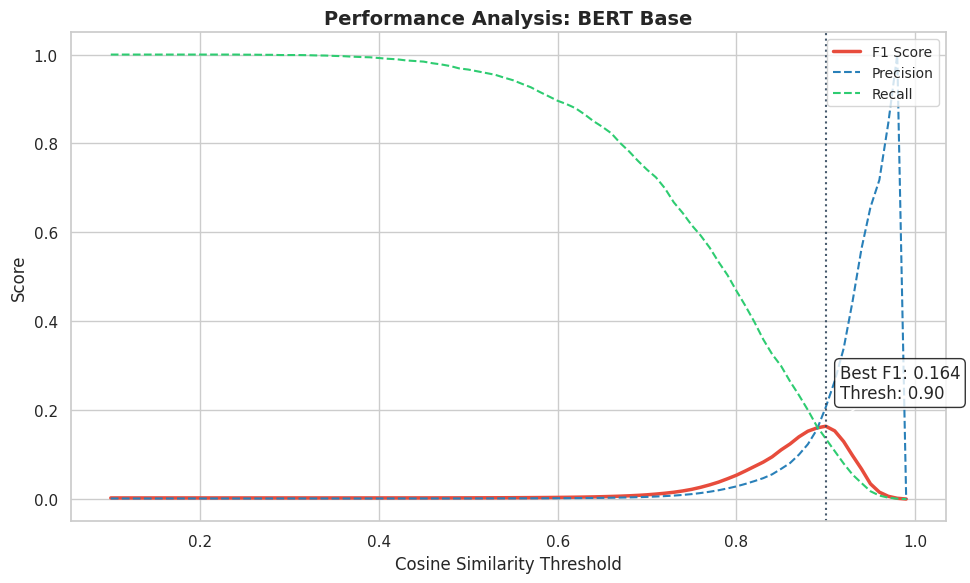

In [4]:
all_summary_data = []

# Map raw names to display names for later
display_names_map = {k: v['display_name'] for k, v in config.MODELS.items()}

for model_name, model_conf in models_to_test.items():
    print(f"\n{'='*50}")
    print(f" Processing: {model_conf['display_name']}")
    print(f"{'='*50}")

    # Load with specific type (Sentence vs Token)
    model = model_utils_shared.load_model(model_name, model_type=model_conf['type'])
    if model is None:
        continue

    # Compute similarity
    similarities = model_utils.compute_embeddings_and_similarity(
        model, df, batch_size=config.BATCH_SIZE
    )
    
    # Evaluate
    current_model_results, best_threshold = model_utils.evaluate_model(
        model_name, similarities, labels, thresholds=config.THRESHOLDS
    )
    all_summary_data.extend(current_model_results)
    
    # Plot Individual
    model_utils.plot_individual_performance(
        current_model_results, 
        model_name, 
        best_threshold,
        display_name=model_conf['display_name']
    )

## 4. Aggregate Results & Comparison
Compare all models in a single high-quality chart.


Detailed results saved to 'results/cv_results.csv'
Generating comparison plot...
Graph saved to 'results/plots/performance_comparison.svg'


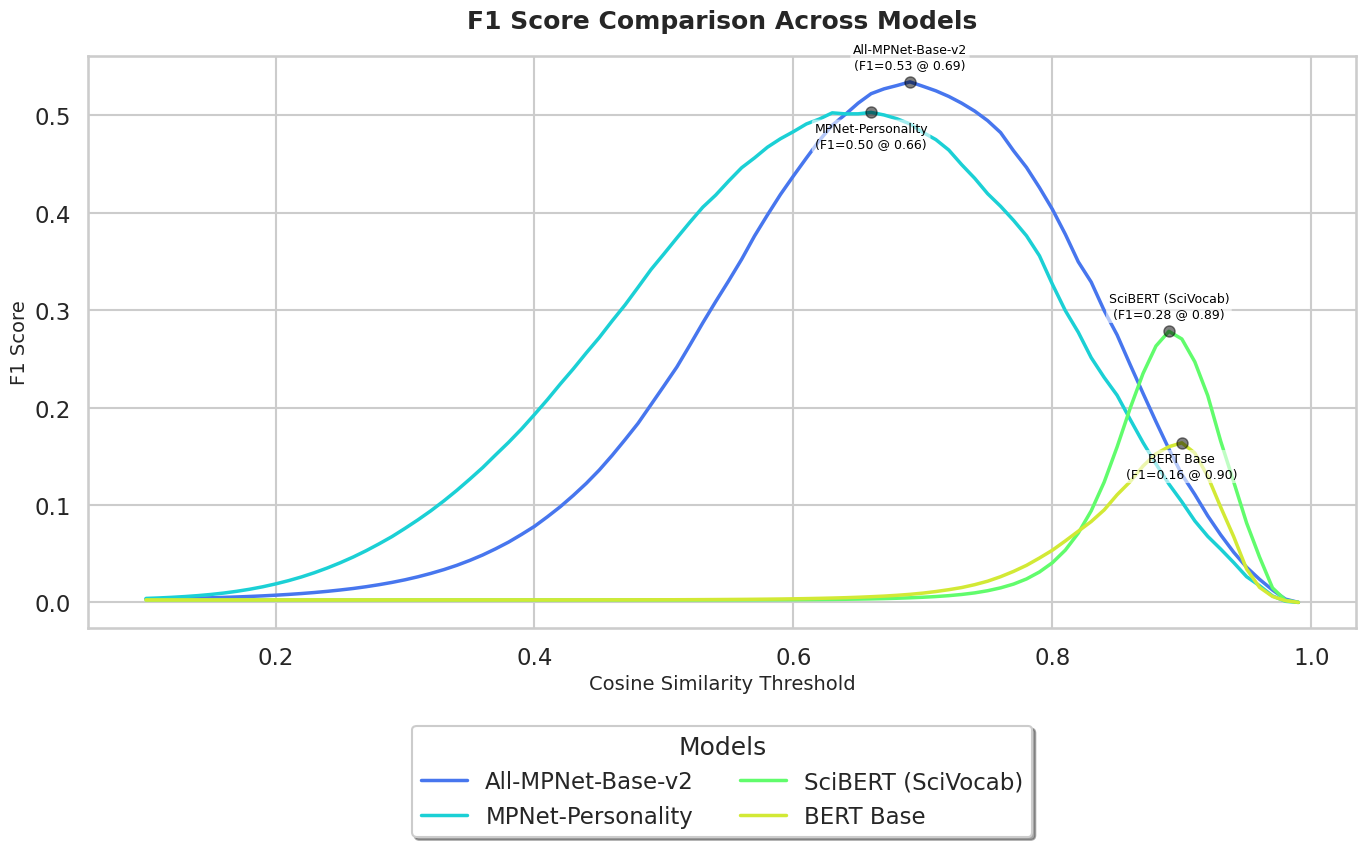


 BEST SETTINGS PER MODEL 
Model: all-mpnet-base-v2
  Optimal Threshold: 0.69
  Max F1 Score:      0.5345
  Precision:         0.5869
  Recall:            0.4907
----------------------------------------
Model: dwulff/mpnet-personality
  Optimal Threshold: 0.66
  Max F1 Score:      0.5031
  Precision:         0.5747
  Recall:            0.4474
----------------------------------------
Model: allenai/scibert_scivocab_uncased
  Optimal Threshold: 0.89
  Max F1 Score:      0.2783
  Precision:         0.3226
  Recall:            0.2448
----------------------------------------
Model: bert-base-uncased
  Optimal Threshold: 0.90
  Max F1 Score:      0.1638
  Precision:         0.2065
  Recall:            0.1358
----------------------------------------


In [5]:
summary_df = pd.DataFrame(all_summary_data)
summary_df.to_csv(config.DATA_PATHS['results_csv'], index=False)
print(f"\nDetailed results saved to '{config.DATA_PATHS['results_csv']}'")

# Plot Comparison
model_utils.plot_comparison(summary_df, model_display_names=display_names_map)

# Print Text Summary
model_utils.print_best_settings(summary_df)